# Prototype — Prédiction de la demande & recommandation de stations

**Tâche T9** (cf. `docs/bloc2/planning.md`) — Responsable : Lyes (Data Scientist)

Objectifs :
1. Prototyper et **comparer 3 modèles** prédisant le nombre de vélos disponibles à une station donnée, à partir de features temporelles simples (heure, jour de la semaine) et de caractéristiques de la station (capacité, commune) : régression linéaire (baseline), Random Forest (bagging), Gradient Boosting (boosting).
2. Esquisser un système de recommandation : suggérer la station la plus proche disposant d'un vélo disponible.

**Limite assumée du MVP** : ~2 jours d'historique disponibles à ce stade (cf. `01_statistiques_descriptives.ipynb`) — largement insuffisant pour un modèle de production (il faudrait plusieurs semaines pour capturer la saisonnalité hebdomadaire). Ce notebook démontre la mécanique du pipeline ML (feature engineering → entraînement → évaluation) sur les données réellement disponibles, prête à être ré-entraînée à mesure que l'historique grossit.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

load_dotenv(Path('../../.env'))

engine = create_engine(
    f"postgresql+pg8000://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}"
    f"@{os.environ.get('POSTGRES_HOST', 'localhost')}:{os.environ.get('POSTGRES_PORT', '5432')}"
    f"/{os.environ['POSTGRES_DB']}"
)

stations = pd.read_sql('SELECT * FROM stations', engine)

query = """
    SELECT d.station_id, d.num_bikes_available, d.num_docks_available, d.observed_at,
           s.capacity, s.commune, s.latitude, s.longitude
    FROM disponibilite_releve d
    JOIN stations s ON s.station_id = d.station_id
    WHERE s.capacity > 0
"""
data = pd.read_sql(query, engine)
data['observed_at'] = pd.to_datetime(data['observed_at'])
print(f"{len(data)} observations chargées pour {data['station_id'].nunique()} stations")

3099 observations chargées pour 234 stations


## 1. Feature engineering

In [2]:
data['heure'] = data['observed_at'].dt.hour
data['jour_semaine'] = data['observed_at'].dt.dayofweek  # 0 = lundi
data = data.dropna(subset=['capacity', 'commune'])

features = ['heure', 'jour_semaine', 'capacity', 'commune', 'station_id']
target = 'num_bikes_available'

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train : {len(X_train)} lignes — Test : {len(X_test)} lignes')

Train : 2479 lignes — Test : 620 lignes


## 2. Entraînement et comparaison de 3 modèles

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), ['commune', 'station_id']),
    ],
    remainder='passthrough',
)

candidats = {
    'Régression linéaire': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
}

resultats = []
modeles_entraines = {}

for nom, regressor in candidats.items():
    pipeline = Pipeline(steps=[('preprocess', preprocessor), ('regressor', regressor)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    resultats.append({
        'modèle': nom,
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'R2': round(r2_score(y_test, y_pred), 3),
    })
    modeles_entraines[nom] = pipeline

comparaison = pd.DataFrame(resultats).sort_values('R2', ascending=False).reset_index(drop=True)
display(comparaison)

,modèle,MAE,RMSE,R2
0,Random Forest,4.19,5.75,0.716
1,Gradient Boosting,4.67,6.25,0.665
2,Régression linéaire,4.38,6.34,0.655


## 3. Comparaison visuelle des scores

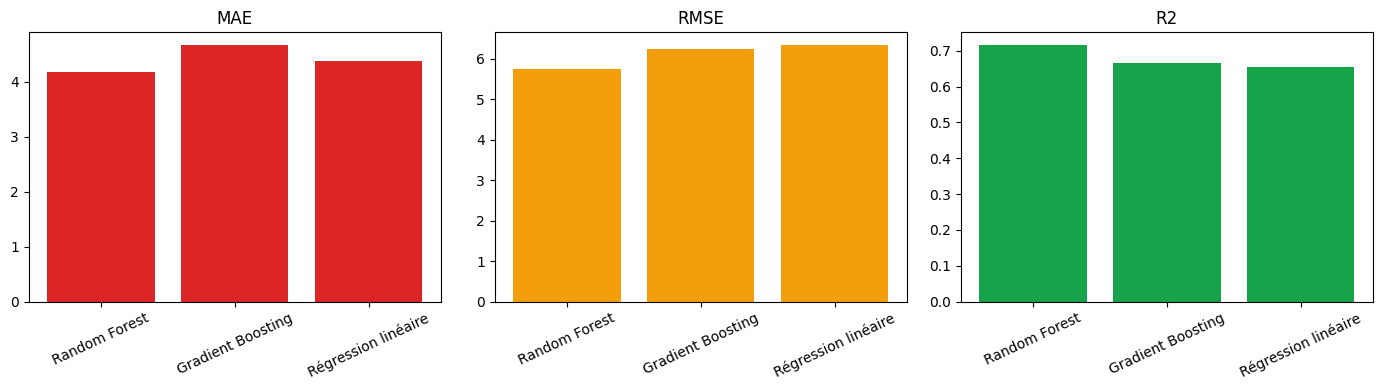

Meilleur modèle (R² le plus élevé) : Random Forest


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
couleurs = {'MAE': '#dc2626', 'RMSE': '#f59e0b', 'R2': '#16a34a'}
for ax, metrique in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(comparaison['modèle'], comparaison[metrique], color=couleurs[metrique])
    ax.set_title(metrique)
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

meilleur_modele_nom = comparaison.iloc[0]['modèle']
meilleur_modele = modeles_entraines[meilleur_modele_nom]
print(f'Meilleur modèle (R² le plus élevé) : {meilleur_modele_nom}')

## 4. Prédiction vs réalité (meilleur modèle)

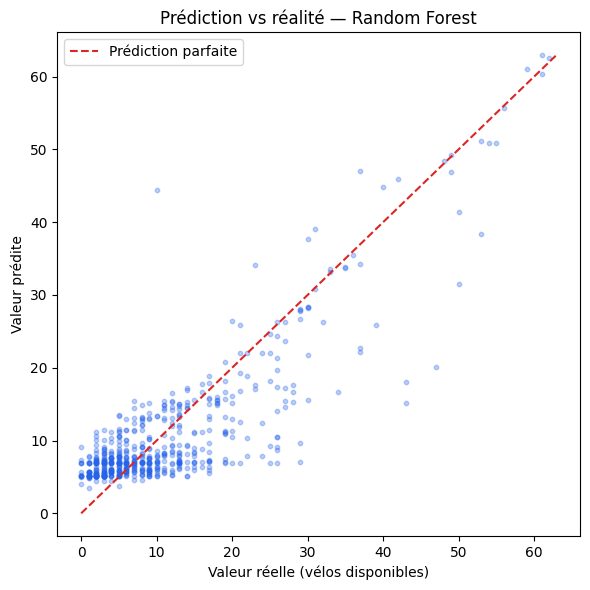

In [5]:
y_pred_best = meilleur_modele.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.3, color='#2563eb', s=10)
lims = [0, max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, color='#dc2626', linestyle='--', label='Prédiction parfaite')
ax.set_xlabel('Valeur réelle (vélos disponibles)')
ax.set_ylabel('Valeur prédite')
ax.set_title(f'Prédiction vs réalité — {meilleur_modele_nom}')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Importance des variables (meilleur modèle)

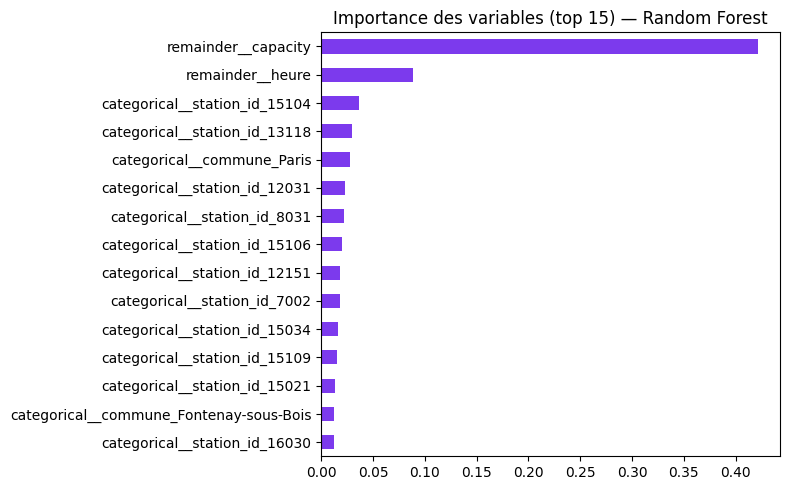

In [6]:
regressor_entraine = meilleur_modele.named_steps['regressor']

if hasattr(regressor_entraine, 'feature_importances_'):
    importances = regressor_entraine.feature_importances_
    feature_names = meilleur_modele.named_steps['preprocess'].get_feature_names_out()
    top_features = (
        pd.Series(importances, index=feature_names)
        .sort_values(ascending=False)
        .head(15)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    top_features.sort_values().plot(kind='barh', ax=ax, color='#7c3aed')
    ax.set_title(f'Importance des variables (top 15) — {meilleur_modele_nom}')
    plt.tight_layout()
    plt.show()
else:
    print(f"{meilleur_modele_nom} n'expose pas nativement d'importance de variables (modèle linéaire).")

## 6. Esquisse d'un système de recommandation

Recommande, à partir d'une position (latitude/longitude), les stations les plus proches disposant d'un vélo (ou d'une place libre), en s'appuyant sur le dernier relevé connu de chaque station et la distance à vol d'oiseau (formule de haversine).

In [7]:
from math import atan2, cos, radians, sin, sqrt


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(dlambda / 2) ** 2
    return 2 * r * atan2(sqrt(a), sqrt(1 - a))


def recommander_station(lat_utilisateur, lon_utilisateur, besoin='velo', top_n=3):
    """Recommande les stations les plus proches disposant d'un velo (besoin='velo')
    ou d'une place libre (besoin='dock'), a partir du dernier releve connu par station."""
    dernier_releve = data.sort_values('observed_at').groupby('station_id').tail(1).copy()
    if besoin == 'velo':
        dernier_releve = dernier_releve[dernier_releve['num_bikes_available'] > 0]
    else:
        dernier_releve = dernier_releve[dernier_releve['num_docks_available'] > 0]

    dernier_releve = dernier_releve.merge(stations[['station_id', 'name']], on='station_id', how='left')
    dernier_releve['distance_km'] = dernier_releve.apply(
        lambda r: haversine_km(lat_utilisateur, lon_utilisateur, r['latitude'], r['longitude']), axis=1
    )
    return dernier_releve.sort_values('distance_km')[
        ['name', 'distance_km', 'num_bikes_available', 'num_docks_available']
    ].head(top_n)

In [8]:
# Exemple : utilisateur situé près de Notre-Dame de Paris (48.8530, 2.3499)
recommander_station(48.8530, 2.3499, besoin='velo')

,name,distance_km,num_bikes_available,num_docks_available
217,Mutualité,0.531648,9,27
28,Panthéon - Valette,0.709945,2,49
143,Quai de l'Horloge - Pont Neuf,0.745000,3,13


## Conclusion et pistes d'amélioration

- La comparaison des 3 modèles (régression linéaire, Random Forest, Gradient Boosting) montre que les modèles à base d'arbres (ensemblistes) capturent mieux les interactions entre station/heure/jour que la régression linéaire — cf. tableau `comparaison` et graphiques ci-dessus pour les scores exacts obtenus sur ce jeu de données.
- L'historique disponible (~2 jours) reste trop court pour espérer capturer une saisonnalité hebdomadaire fiable — **à ré-entraîner et recomparer** une fois plusieurs semaines de données accumulées.
- Le système de recommandation est une esquisse fonctionnelle (distance à vol d'oiseau) : une version aboutie utiliserait un temps de trajet réel (API routing) et le sens de circulation.
- Piste d'industrialisation : exposer `meilleur_modele.predict` et `recommander_station` via une petite API (FastAPI) consommée par le tableau de bord Data Analyst (T7), et planifier le ré-entraînement/la recomparaison des 3 modèles en tâche batch (cf. `docs/bloc4/plan_maintenance.md`, pistes d'amélioration — ordonnanceur Airflow/cron).